# Laboratorul I
## Tema: Utilizarea diferitor algoritmi de clusterizare pe diferite tipuri de date. Vizualizarea datelor.
Efectuat: Perebinos Daniel

### Instalarea dependentelor

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn

### 

### Algoritmi partiţionali (KMeans)

Principiul de lucru al KMeans constă în împărțirea datelor în k clustere pe baza distanței minime față de centrele (centroizii) clusterelor. Algoritmul ajustează centrele iterativ până când acestea converg, minimizând suma pătratelor distanțelor dintre puncte și centroizi.

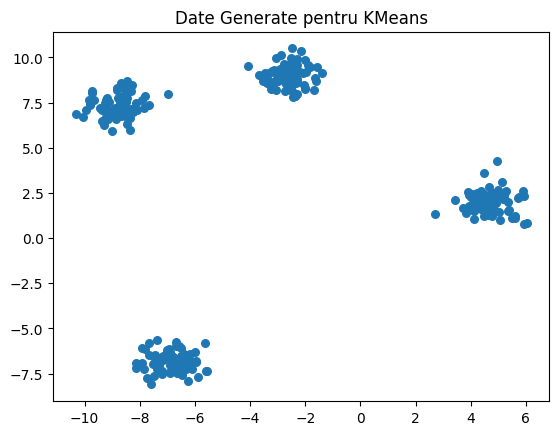

In [2]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)
plt.scatter(X[:, 0], X[:, 1], s=30)
plt.title("Date Generate pentru KMeans")
plt.show()

In [3]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)
labels = kmeans.labels_

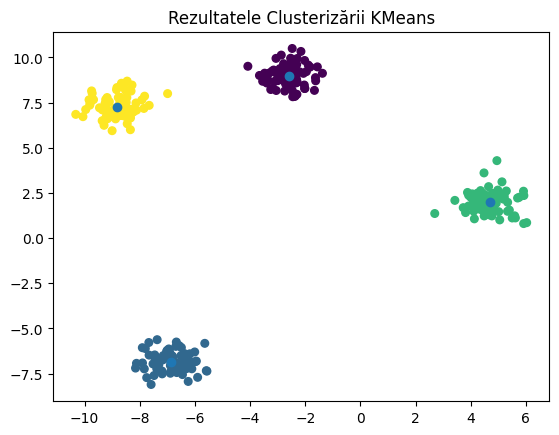

In [4]:
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1])
plt.title("Rezultatele Clusterizării KMeans")
plt.show()

In [5]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, labels)
print(f"Silhouette Score pentru KMeans: {score:.2f}")

Silhouette Score pentru KMeans: 0.88


### Algoritmi hierarhici (AgglomerativeClustering)

Algoritmul aglomerativ începe prin considerarea fiecărui punct ca un cluster separat, apoi combină succesiv clusterele cele mai apropiate. Procesul continuă până când toate punctele formează un singur cluster sau este atins un număr specificat de clustere.

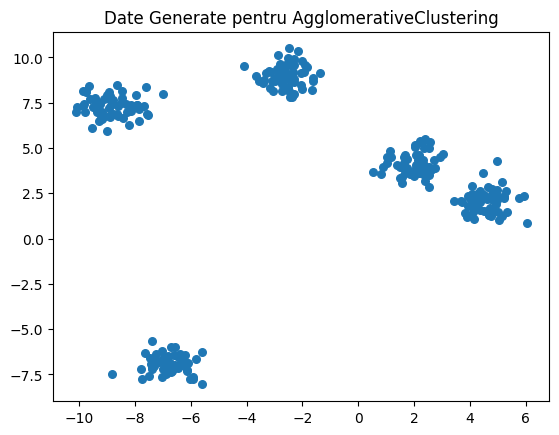

In [6]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=5, cluster_std=0.60, random_state=42)
plt.scatter(X[:, 0], X[:, 1], s=30)
plt.title("Date Generate pentru AgglomerativeClustering")
plt.show()

In [7]:
from sklearn.cluster import AgglomerativeClustering

agg_clustering = AgglomerativeClustering(n_clusters=5)
labels = agg_clustering.fit_predict(X)

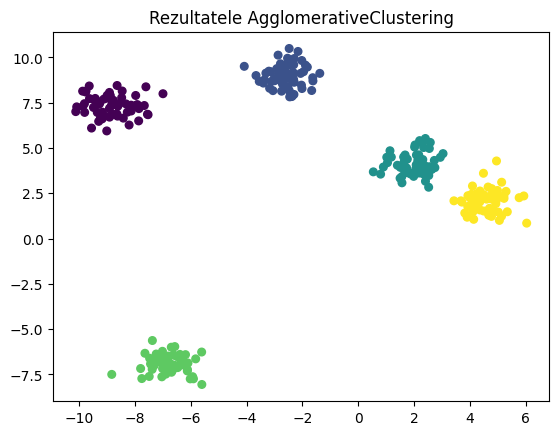

In [8]:
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30)
plt.title("Rezultatele AgglomerativeClustering")
plt.show()

In [9]:
score = silhouette_score(X, labels)
print(f"Silhouette Score pentru AgglomerativeClustering: {score:.2f}")

Silhouette Score pentru AgglomerativeClustering: 0.79


### Algoritmi bazaţi pe densitate (DBSCAN)

DBSCAN identifică clusterele pe baza densității punctelor, grupând punctele apropiate și marcând cele izolate drept zgomot. Algoritmul nu necesită specificarea numărului de clustere, ci depinde de distanța minimă dintre puncte și numărul minim de vecini.

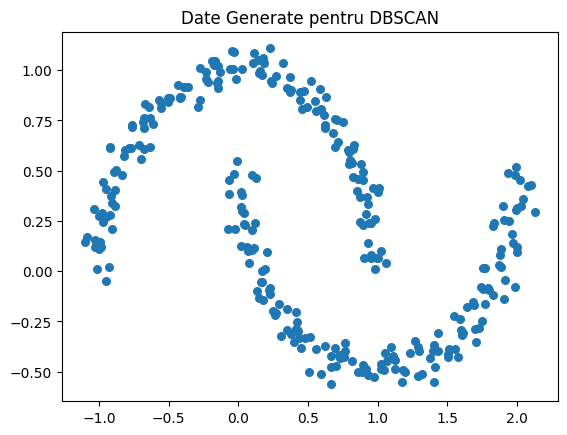

In [10]:
from sklearn.datasets import make_moons

X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

plt.scatter(X[:, 0], X[:, 1], s=30)
plt.title("Date Generate pentru DBSCAN")
plt.show()

In [11]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

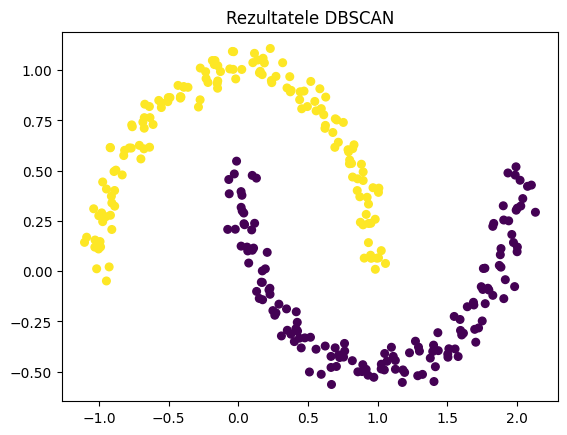

In [12]:
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30)
plt.title("Rezultatele DBSCAN")
plt.show()

In [13]:
score = silhouette_score(X, labels)
print(f"Silhouette Score pentru DBSCAN: {score:.2f}")

Silhouette Score pentru DBSCAN: 0.33


### Algoritmi bazați pe modele probabiliste (GaussianMixture)

GaussianMixture presupune că datele sunt generate din mai multe distribuții Gaussiane și utilizează metoda Expectation-Maximization (EM) pentru a estima parametrii acestor distribuții. Fiecare punct primește o probabilitate de apartenență la un cluster, iar estimările se ajustează iterativ până la convergență.

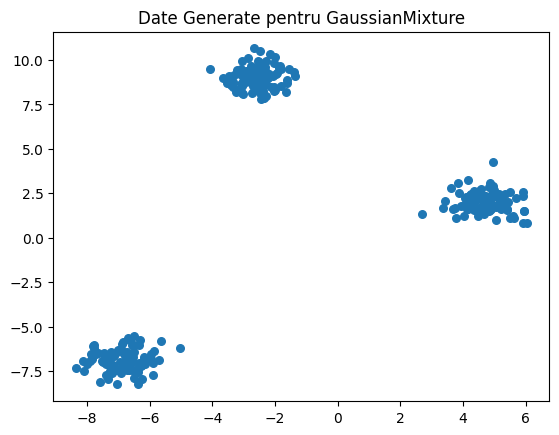

In [14]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=42)
plt.scatter(X[:, 0], X[:, 1], s=30)
plt.title("Date Generate pentru GaussianMixture")
plt.show()

In [15]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X)
labels = gmm.predict(X)

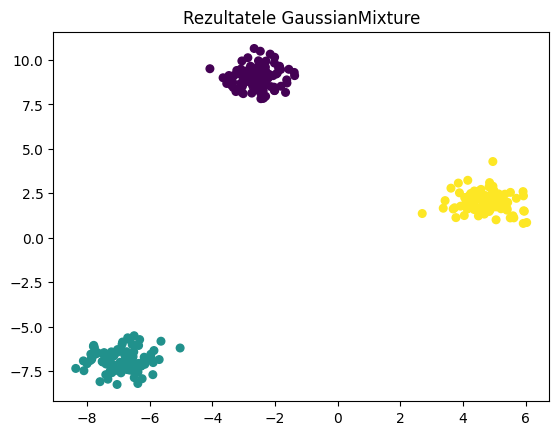

In [16]:
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30)
plt.title("Rezultatele GaussianMixture")
plt.show()

In [17]:
score = silhouette_score(X, labels)
print(f"Silhouette Score pentru GaussianMixture: {score:.2f}")

Silhouette Score pentru GaussianMixture: 0.91


### Concluzie

În acest laborator, am explorat patru tipuri de algoritmi de clusterizare: KMeans, AgglomerativeClustering, DBSCAN și GaussianMixture. Fiecare algoritm a fost aplicat pe seturi de date generate, evidențiind modul în care funcționează în funcție de forma și structura datelor. Am observat că KMeans și GaussianMixture funcționează bine pentru date cu clustere bine separate, în timp ce DBSCAN este mai eficient pentru date cu forme neregulate și poate identifica zgomotul. AgglomerativeClustering a demonstrat o abordare flexibilă pentru datele ierarhice. Evaluarea cu Silhouette Score a confirmat performanța fiecărui algoritm, subliniind importanța alegerii metodei potrivite în funcție de caracteristicile datelor.